# Data Preprocessing

In this notebook, we will prepare the raw dataset for machine learning.

## Objectives

- Understand missing values
- Handle categorical and numerical features
- Remove unnecessary columns
- Create a clean dataset for modeling

> **Note:** We will make preprocessing decisions based on data analysis rather than fixed rules.

In [1]:
import pandas as pd 
import numpy as np

df= pd.read_csv("../data/raw/application_train.csv")
print(df.shape)

df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Initial Observation

The dataset contains **307,511** loan applications and **122** features.

Before building a model, we need to understand:

- Which columns have missing values?
- Which features are categorical?
- Which features are numerical?
- Which columns should be removed or transformed?

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


# Step 2: Missing Value Analysis

Missing values are common in real-world datasets.

Before deciding whether to remove or fill them, we must answer:

- Which columns contain missing values?
- How many values are missing?
- What percentage of each column is missing?

We will use percentages because they are easier to compare across columns.

In [3]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing.head(20)

,Missing Count,Missing Percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


# Step 3: Investigating Highly Missing Columns

Many of the columns with the highest percentage of missing values belong to the same family.

Examples:

- COMMONAREA_AVG
- COMMONAREA_MEDI
- COMMONAREA_MODE

These represent different statistical summaries of the same underlying feature.

Before removing any column, we will investigate whether these features provide useful predictive information.

In [4]:
missing[
    missing["Missing Percentage"] < 5
].head(20)

,Missing Count,Missing Percentage
NAME_TYPE_SUITE,1292,0.420148
DEF_60_CNT_SOCIAL_CIRCLE,1021,0.332021
OBS_60_CNT_SOCIAL_CIRCLE,1021,0.332021
DEF_30_CNT_SOCIAL_CIRCLE,1021,0.332021
OBS_30_CNT_SOCIAL_CIRCLE,1021,0.332021
EXT_SOURCE_2,660,0.214626
AMT_GOODS_PRICE,278,0.090403
AMT_ANNUITY,12,0.003902
CNT_FAM_MEMBERS,2,0.000650
DAYS_LAST_PHONE_CHANGE,1,0.000325


# Step 4: Missing Value Strategy

After analyzing the missing values, we observe that not all columns require the same treatment.

Instead of applying a single rule to the entire dataset, we categorize columns based on the percentage of missing values.

Our strategy will be:

- Very low missing values (<1%) → Impute
- Moderate missing values (1–40%) → Investigate and impute
- High missing values (>40%) → Investigate carefully before deciding whether to keep or remove

This approach preserves useful information while minimizing unnecessary data loss.

# Step 5: Separate Numerical and Categorical Features

Different data types require different preprocessing techniques.

Numerical Features:
- Median or Mean Imputation
- Scaling
- Outlier Handling

Categorical Features:
- Mode Imputation
- Encoding

In [5]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = df.select_dtypes(include="str").columns

print("Numerical Columns:", len(numerical_cols))
print("Categorical Columns:", len(categorical_cols))

Numerical Columns: 106
Categorical Columns: 16


# Step 6: Imputation Strategy

Machine learning algorithms cannot train on missing values.

Based on our exploratory data analysis:

- Numerical features contain outliers.
- Therefore, we will use the **median** for numerical imputation because it is robust to extreme values.
- Categorical features will be imputed using the **mode** (most frequent category).

This strategy preserves as much information as possible while handling missing values consistently.

# Step 7: Preventing Data Leakage

Before applying any preprocessing technique, we must split the dataset into training and testing sets.

Why?

Preprocessing techniques such as:

- Median Imputation
- Standard Scaling
- One-Hot Encoding

must learn their parameters **only from the training data**.

The same learned transformations are then applied to the test data.

This prevents **data leakage** and ensures a fair evaluation of the model.

# Step 8: Separate Features and Target

Machine learning models learn from the input features (X) to predict the target variable (y).

We first separate the target column from the feature columns before creating training and testing datasets.

In [6]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop(columns=["TARGET"])

# Target
y = df["TARGET"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (307511, 121)
y Shape: (307511,)


## Train-Test Split

Split the dataset into training and testing sets.

Since the target is imbalanced, we'll use `stratify=y` to preserve the class distribution in both sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (246008, 121)
Test : (61503, 121)


In [8]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = X.select_dtypes(include="str").columns

## Create Preprocessing Pipeline

We'll create separate preprocessing steps for numerical and categorical features.

- Numerical: Median Imputation
- Categorical: Most Frequent Imputation + One-Hot Encoding

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [10]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


In [11]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [12]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## Build the Machine Learning Pipeline

Combine preprocessing and the machine learning model into a single pipeline.

This ensures that the same preprocessing steps are automatically applied during both training and prediction.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [14]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

In [15]:
model.fit(X_train, y_train)

e:\new\loan-default-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](121,)","['SK_ID_CURR','NAME_CONTRACT_TYPE','CODE_GENDER',..., 'AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,121
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are drop

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [17]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [18]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.9193
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC AUC  : 0.6286


e:\new\loan-default-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



e:\new\loan-default-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\new\loan-default-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\new\loan-default-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

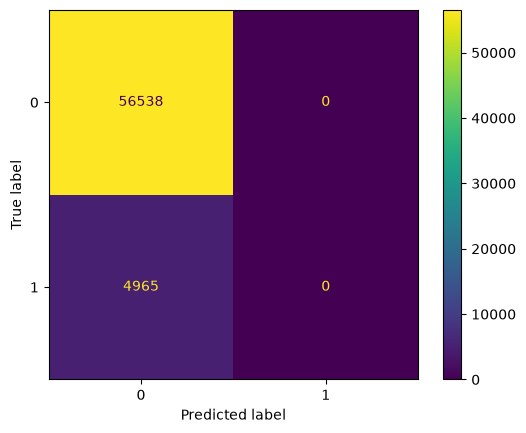

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## Improve Baseline Model

The dataset is highly imbalanced.

We'll assign a higher penalty to mistakes on the minority class using `class_weight="balanced"`.

In [21]:
balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [22]:
balanced_model.fit(X_train, y_train)

e:\new\loan-default-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](121,)","['SK_ID_CURR','NAME_CONTRACT_TYPE','CODE_GENDER',..., 'AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,121
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are drop

In [23]:
y_pred = balanced_model.predict(X_test)
y_prob = balanced_model.predict_proba(X_test)[:, 1]

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.59      0.73     56538
           1       0.11      0.59      0.19      4965

    accuracy                           0.59     61503
   macro avg       0.53      0.59      0.46     61503
weighted avg       0.88      0.59      0.68     61503



In [25]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.5898
Precision: 0.1124
Recall   : 0.5917
F1 Score : 0.1889
ROC AUC  : 0.6210


## Threshold Tuning

By default, Logistic Regression predicts class 1 when the predicted probability is **0.5 or higher**.

Changing this threshold allows us to balance **Precision** and **Recall** based on the business problem.

In [26]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    print(f"\nThreshold = {t}")
    print(f"Precision : {precision_score(y_test, y_pred):.3f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.3f}")


Threshold = 0.3
Precision : 0.082
Recall    : 0.976

Threshold = 0.4
Precision : 0.091
Recall    : 0.875

Threshold = 0.5
Precision : 0.112
Recall    : 0.592

Threshold = 0.6
Precision : 0.149
Recall    : 0.180

Threshold = 0.7
Precision : 0.133
Recall    : 0.013


## Threshold Tuning

The default prediction threshold is **0.5**.

- Lower threshold → Higher Recall, Lower Precision
- Higher threshold → Lower Recall, Higher Precision

The optimal threshold depends on the business objective.

## ROC Curve

The ROC Curve shows how the True Positive Rate (Recall) changes against the False Positive Rate for different classification thresholds.

The Area Under the Curve (ROC-AUC) summarizes the model's ranking ability.

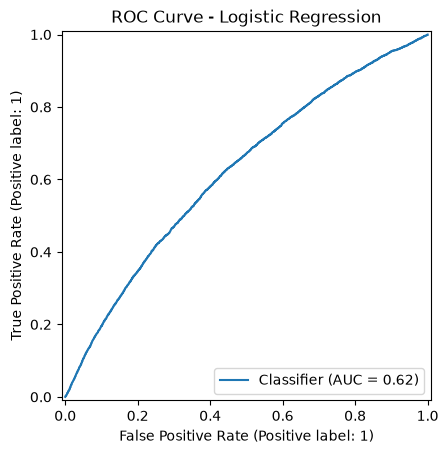

In [27]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve - Logistic Regression")
plt.show()

## Random Forest Baseline

Random Forest is an ensemble learning algorithm that combines many decision trees.

It can model complex, non-linear relationships and often performs better than linear models on tabular datasets.

In [28]:
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [29]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](121,)","['SK_ID_CURR','NAME_CONTRACT_TYPE','CODE_GENDER',..., 'AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,121
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are drop

In [30]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [31]:
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall   : {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, rf_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, rf_prob):.4f}")

Accuracy : 0.9194
Precision: 1.0000
Recall   : 0.0014
F1 Score : 0.0028
ROC AUC  : 0.7059


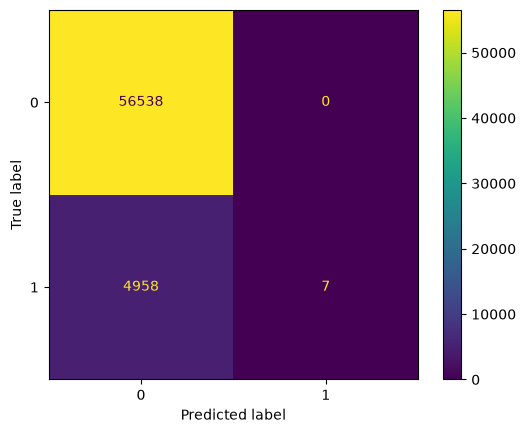

In [32]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.show()

In [33]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    pred = (rf_prob >= t).astype(int)

    print(f"\nThreshold = {t}")
    print(f"Precision : {precision_score(y_test, pred):.3f}")
    print(f"Recall    : {recall_score(y_test, pred):.3f}")
    print(f"F1 Score  : {f1_score(y_test, pred):.3f}")


Threshold = 0.2
Precision : 0.256
Recall    : 0.254
F1 Score  : 0.255

Threshold = 0.3
Precision : 0.403
Recall    : 0.079
F1 Score  : 0.132

Threshold = 0.4
Precision : 0.529
Recall    : 0.015
F1 Score  : 0.028

Threshold = 0.5
Precision : 0.875
Recall    : 0.001
F1 Score  : 0.003

Threshold = 0.6
Precision : 0.000
Recall    : 0.000
F1 Score  : 0.000


e:\new\loan-default-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Credit-to-Income Ratio

This feature measures how large the requested loan is compared to the applicant's annual income.

Higher values may indicate higher financial risk.

In [34]:
df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
)

C:\Users\mohit\AppData\Local\Temp\ipykernel_18600\4268932025.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["CREDIT_INCOME_RATIO"] = (


### Annuity-to-Income Ratio

Measures how much of the applicant's income is required to pay the loan annuity.

Higher ratios may indicate repayment difficulty.

In [35]:
df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

C:\Users\mohit\AppData\Local\Temp\ipykernel_18600\2304178591.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ANNUITY_INCOME_RATIO"] = (


In [36]:
df["AGE_YEARS"] = (
    -df["DAYS_BIRTH"] / 365
)

C:\Users\mohit\AppData\Local\Temp\ipykernel_18600\1759206150.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE_YEARS"] = (


In [37]:
df["EMPLOYMENT_YEARS"] = (
    -df["DAYS_EMPLOYED"] / 365
)

C:\Users\mohit\AppData\Local\Temp\ipykernel_18600\103846344.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EMPLOYMENT_YEARS"] = (


In [38]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [39]:
(df["DAYS_EMPLOYED"] == 365243).sum()

np.int64(55374)

In [40]:
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365
df["EMPLOYMENT_YEARS"].describe()



count    252137.000000
mean          6.531971
std           6.406466
min          -0.000000
25%           2.101370
50%           4.515068
75%           8.698630
max          49.073973
Name: EMPLOYMENT_YEARS, dtype: float64

In [41]:
# Loan amount relative to income
df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]

# Annual loan payment relative to income
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

# Loan relative to goods price
df["CREDIT_GOODS_RATIO"] = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"]

# Income per family member
df["INCOME_PER_FAMILY"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]

# Credit per family member
df["CREDIT_PER_FAMILY"] = df["AMT_CREDIT"] / df["CNT_FAM_MEMBERS"]

# Age in years
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365

# Employment years
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365

# Employment to age ratio
df["EMPLOYMENT_AGE_RATIO"] = (
    df["EMPLOYMENT_YEARS"] / df["AGE_YEARS"]
)

C:\Users\mohit\AppData\Local\Temp\ipykernel_18600\1640067858.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["CREDIT_GOODS_RATIO"] = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"]
C:\Users\mohit\AppData\Local\Temp\ipykernel_18600\1640067858.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["INCOME_PER_FAMILY"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
C:\Users\mohit\AppData\Local\Temp\ipykernel_18600\1640067858.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.